In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="0,1,2,3"

In [2]:
!pip install transformers
#from google.colab import drive
#drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 99.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 618.0/618.0 kB 42.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 95.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 106.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [transformers] [transformers]ub]


In [63]:
import torch
import random
import numpy as np
import pandas as pd
from torch import nn
from tqdm import tqdm
from pprint import pprint
from torch.optim import Adam
from sklearn.metrics import f1_score
from sklearn.datasets import load_files
from sklearn.metrics import classification_report, confusion_matrix
from transformers import BertTokenizer, BertModel
from sklearn.model_selection import train_test_split

In [4]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

In [5]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
print (tokenizer.tokenize("How do I learn this laern"))
print (tokenizer.tokenize("I have a new GPU!"))
pprint (tokenizer("How do I learn this laern", padding='max_length',
         max_length = 32, truncation=True, return_tensors="pt"))
# return_tensors = "pt" is just for the tokenizer to return PyTorch tensors.
# If you don’t want this to happen (maybe you want it to return a list),
# then you can remove the parameter and it will return lists.

# Outputs:
# **input_ids**: Indices of input sequence tokens in the vocabulary. 101 is [CLS] token and 102 is [SEP] token.
# **token_type_ids**: Segment token indices to indicate first and second portions of the inputs. 0 for sentence A and 1 for sentence B.
# **attention_mask**: Mask to avoid performing attention on padding token indices. 0 for masked and 1 for not masked.

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

['how', 'do', 'i', 'learn', 'this', 'la', '##ern']
['i', 'have', 'a', 'new', 'gp', '##u', '!']
{'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0]]),
 'input_ids': tensor([[  101,  2129,  2079,  1045,  4553,  2023,  2474, 11795,   102,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0]]),
 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0]])}


In [7]:
print (tokenizer.vocab)
# 0 = [PAD]
# 1..99 = [unused1] … [unused99]: repurposing these can work, but often it’s cleaner to add your own special tokens explicitly and resize embeddings.
# 100 = [UNK]
# 101 = [CLS]
# 102 = [SEP]
# 103 = [MASK]

{'caroline': 7981, '##overs': 24302, 'apron': 20376, 'exclaimed': 12713, 'fingered': 28842, '##ng': 3070, 'ric': 26220, '##:': 29627, 'proportion': 10817, 'crate': 27297, 'corrected': 13371, 'father': 2269, '宣': 1823, '##zcz': 29419, 'horton': 18469, 'joined': 2587, 'reginald': 14435, '¶': 1086, 'sans': 20344, 'casually': 13217, 'crashes': 19119, 'amend': 27950, '##ifer': 23780, '##安': 30346, 'somethin': 27941, 'retained': 6025, 'percy': 11312, '[unused628]': 633, '1648': 22533, '##sk': 6711, 'elaine': 15263, 'wielding': 26974, 'kassel': 27884, 'shrieked': 22383, 'wife': 2564, 'eighties': 27690, '##lene': 11474, 'australia': 2660, 'twin': 5519, 'thong': 27468, '##ᅮ': 30014, 'milk': 6501, 'capturing': 11847, '∈': 1596, 'contributors': 16884, 'tricky': 24026, 'representation': 6630, 'asleep': 6680, 'sandstone': 11694, 'variables': 10857, 'mendoza': 18021, '##ropriation': 26121, '##₤': 30100, '##master': 8706, '[unused880]': 885, 'excluding': 13343, '##orted': 15613, 'revolves': 19223, '#

In [8]:
def set_seed(seed):
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

In [9]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, docs, ys):
        self.labels = ys.tolist()
        self.texts = [tokenizer(text.decode("utf-8"), # dataset is bytes
                                padding='max_length', max_length = 512, truncation=True, # BERT's max window size is 512
                                return_tensors="pt") for text in docs]

    def classes(self):
        return self.labels

    def __len__(self):
        return len(self.labels)

    def get_batch_labels(self, idx):
        # Fetch a batch of labels
        return np.array(self.labels[idx])

    def get_batch_texts(self, idx):
        # Fetch a batch of inputs
        return self.texts[idx]

    def __getitem__(self, idx):
        batch_texts = self.get_batch_texts(idx)
        batch_y = self.get_batch_labels(idx)
        return batch_texts, batch_y

For bert-base, there are:  
12 encoder layers (24 for bert-large)

If freeze_layer_count = 3, it usually means:  
- freeze encoder layers 0, 1, 2  
- train layers 3–11 and the classifier head

Freezing layers can:  
- reduce training time  
- reduce GPU memory use a bit  
- help prevent overfitting on small datasets  
- preserve general pretrained language features in lower layers  

Lower BERT layers tend to learn more general syntax/token features, while higher layers are more task-specific.

Typical intuition:  
- lower layers: basic language structure  
- middle layers: richer contextual features  
- upper layers: more task-adaptable features  

In [11]:
class BertClassifier(nn.Module):
    def __init__(self, dropout=0.2, freeze_layer_count=6):
        super(BertClassifier, self).__init__() # initialize the attributes of the parent class
        self.bert = BertModel.from_pretrained('bert-base-uncased') # uncased lowercases the text before tokenization

        # Freeze bert layers
        if freeze_layer_count:
            # We freeze here the embeddings of the model
            for param in self.bert.embeddings.parameters():
                param.requires_grad = False

            if freeze_layer_count != -1:
                # if freeze_layer_count == -1, we only freeze the embedding layer
                # otherwise we freeze the first `freeze_layer_count` encoder layers
                for layer in self.bert.encoder.layer[:freeze_layer_count]:
                    for param in layer.parameters():
                        param.requires_grad = False

        self.dropout = nn.Dropout(dropout)
        # At the end of the linear layer, we have a vector of size 2,
        # each corresponds to a category of our labels {0, 1}.
        self.linear = nn.Linear(768, 2) # 768 is the hidden size of bert-base

    def forward(self, input_id, mask):
        # BERT model outputs two variables:
        # The first variable, which we named _ in the code below,
        # contains the embedding vectors of all of the tokens in a sequence.
        # The second variable, which we named pooled_output, contains the embedding vector of [CLS] token.
        # For a text classification task, it is enough to use this embedding as an input for our classifier.
        _, pooled_output = self.bert(input_ids=input_id, attention_mask=mask, return_dict=False)
        # return_dict:
        # https://stackoverflow.com/questions/65132144/bertmodel-transformers-outputs-string-instead-of-tensor
        # We then pass the pooled_output variable into a linear layer with ReLU activation function.
        dropout_output = self.dropout(pooled_output)
        linear_output = self.linear(dropout_output)
        return linear_output

In [64]:
def evaluate(model, eval_dataloader):
    total_acc = 0
    total_loss = 0

    criterion = nn.CrossEntropyLoss()

    eval_labels, eval_preds = [], []
    with torch.no_grad():
        for eval_input, eval_label in eval_dataloader:
            eval_label = eval_label.type(torch.LongTensor).to(device)

            input_ids = eval_input['input_ids'].squeeze(1).to(device)
            attention_mask = eval_input['attention_mask'].squeeze(1).to(device)

            output = model(input_ids, attention_mask)

            batch_loss = criterion(output, eval_label)
            total_loss += batch_loss.item()

            acc = (output.argmax(dim=1) == eval_label).sum().item()
            total_acc += acc

            eval_labels.extend(eval_label.tolist())
            eval_preds.extend(output.argmax(dim=1).tolist())

        # Validation F1-macro
        f1_macro = f1_score(y_true=eval_labels, y_pred=eval_preds, average='macro')
        report = classification_report(y_true=eval_labels, y_pred=eval_preds)
        # cm = confusion_matrix(eval_labels, eval_preds)

    return total_acc, total_loss, f1_macro, report, eval_labels, eval_preds

In [51]:
def train_bert(model,
               train_docs, train_ys,
               val_docs, val_ys,
               test_docs, test_ys,
               learning_rate=2e-5, epochs=1, batch_size=16):

    # Start training loop
    print("Start training...")
    print ("==============")
    print(f"{'Epoch':^7} | {'Val Acc':^9} | {'Val F1':^9}")
    print("-"*30)

    train, val, test = Dataset(train_docs, train_ys), Dataset(val_docs, val_ys), Dataset(test_docs, test_ys)

    train_dataloader = torch.utils.data.DataLoader(train, batch_size=batch_size, shuffle=True, worker_init_fn=np.random.seed(0))
    val_dataloader = torch.utils.data.DataLoader(val, batch_size=batch_size, shuffle=True, worker_init_fn=np.random.seed(0))
    test_dataloader = torch.utils.data.DataLoader(test, batch_size=batch_size, shuffle=True, worker_init_fn=np.random.seed(0))

    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr = learning_rate)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)
    # https://pytorch.org/docs/stable/optim.html

    if use_cuda:
        model = model.cuda()
        criterion = criterion.cuda()

    for epoch_num in range(epochs):
        for train_input, train_label in tqdm(train_dataloader, leave=False):
            train_label = train_label.type(torch.LongTensor).to(device)
            input_ids = train_input['input_ids'].squeeze(1).to(device)
            attention_masks = train_input['attention_mask'].squeeze(1).to(device)

            model.train()
            output = model(input_ids, attention_masks)

            batch_loss = criterion(output, train_label)

            model.zero_grad()
            batch_loss.backward()
            optimizer.step()

        model.eval()
        val_acc, val_loss, val_f1, val_report, _ = evaluate(model, val_dataloader)
        print (f"{epoch_num + 1:^7} | {val_acc / len(val_docs):^9.3f} | {val_f1:^9.3f}")

        scheduler.step()

    val_acc, val_loss, val_f1, val_report, val_cm = evaluate(model, val_dataloader)
    print("Validation Confusion Matrix", val_cm)
    test_acc, test_loss, test_f1, test_report, _ = evaluate(model, test_dataloader)
    print (f"Test Accuracy: {test_acc / len(test_docs):.3f}; Test F1: {test_f1:.3f}")
    print ("\n")
    print (test_report)

    return model

In [52]:
# load data using sklearn.datasets.load_files
dataset = load_files("movie-reviews/")

# split the data into train and test
docs_train, docs_test_val, y_train, y_test_val = train_test_split(dataset.data, dataset.target, test_size=0.2, random_state=3)

docs_val, docs_test, y_val, y_test = train_test_split(docs_test_val, y_test_val, test_size=0.5, random_state=3)

print ( len(docs_train), len(y_train) )
print ( len(docs_val), len(y_val) )
print ( len(docs_test), len(y_test) )

1532 1532
192 192
192 192


In [53]:
print(docs_train[0])
print(y_train[0])

b'they should have stuck to the promise emblazoned on the original movie\'s poster : " no sequel . " \nscary movie 2 is nowhere near as funny as its predecessor , and it is not because the wayans brothers , shawn and marlon doing the writing and keenen ivory behind the camera , don\'t try . \nwhat defeats them is the genre they have chosen to spoof . \nthe first movie - an outrageous , low-brow , savage satire of teen slasher flicks such as scream and i know what you did last summer - succeeded because of its take-no-prisoners attitude toward a type of film that was in vogue , familiar and popular . \nin scary movie 2 , the filmmakers take on the haunted house-ghost story format which , if you look at the grosses for such recent lame offerings as the respective remakes of the haunting and house on haunted hill , did not draw audiences nor enter the cultural psyche as did the various teen slasher series . \nscary movie 2 does start off promising with a wonderful spoof of the exorcist , 

In [54]:
print("train:","negative", len([y for y in y_train if y==0]),", positive", len([y for y in y_train if y==1]))
print("val:","negative", len([y for y in y_val if y==0]),", positive", len([y for y in y_val if y==1]))
print("test:","negative", len([y for y in y_test if y==0]),", positive", len([y for y in y_test if y==1]))

train: negative 807 , positive 725
val: negative 92 , positive 100
test: negative 101 , positive 91


In [55]:
# Finding the maximum length of documents
tokenized_data = [doc.decode('utf-8').split(" ") for doc in dataset.data]
max_token_length = max(len(tokens) for tokens in tokenized_data)
max_token_length

2680

## Build a Naive Bayes baseline

In [56]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer

# vectorize the training data
vectorizer = CountVectorizer(stop_words = "english")
X_train = vectorizer.fit_transform(docs_train)

# To Do:
# tune hyperparameters using val set

# fit the model with the training data
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# vectorize the test data and predict
X_test = vectorizer.transform(docs_test)
y_hat_nb = nb_model.predict(X_test)

# get performance
# macro: every class counts equally (calculate per-class, then average)
# micro: every individual prediction counts equally
print("classification report:\n", classification_report(y_test, y_hat_nb))

classification report:
               precision    recall  f1-score   support

           0       0.75      0.79      0.77       101
           1       0.76      0.71      0.73        91

    accuracy                           0.76       192
   macro avg       0.76      0.75      0.75       192
weighted avg       0.76      0.76      0.75       192



## Build a Logistic Regression baseline

In [57]:
from sklearn.linear_model import LogisticRegression

# fit the model
lr_model = LogisticRegression(random_state = 3, solver='liblinear')
lr_model.fit(X_train, y_train)

# To Do:
# tune hyperparameters using val set

y_hat_lr = lr_model.predict(X_test)
print("classification report:\n", classification_report(y_test, y_hat_lr))

classification report:
               precision    recall  f1-score   support

           0       0.79      0.88      0.83       101
           1       0.85      0.74      0.79        91

    accuracy                           0.81       192
   macro avg       0.82      0.81      0.81       192
weighted avg       0.82      0.81      0.81       192



## Use the Pre-Trained BERT for classification

In [60]:
set_seed(3)
pretrained_model = BertClassifier()
if use_cuda:
    pretrained_model = pretrained_model.cuda()

test = Dataset(docs_test, y_test)
test_dataloader = torch.utils.data.DataLoader(test, batch_size=16, shuffle=False, worker_init_fn=np.random.seed(0))
test_acc, test_loss, test_f1, test_report, _ = evaluate(pretrained_model, test_dataloader)
print("classification report:\n", test_report)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


classification report:
               precision    recall  f1-score   support

           0       0.53      0.69      0.60       101
           1       0.49      0.33      0.39        91

    accuracy                           0.52       192
   macro avg       0.51      0.51      0.50       192
weighted avg       0.51      0.52      0.50       192



## Finetune the Pre-Trained BERT on our dataset

In [ ]:
# load pretrained model
# and skip finetuning
# finetuned_model = BertClassifier()
# finetuned_model.load_state_dict(torch.load("bert_classifier.pt", map_location=device))
# finetuned_model.to(device)
# finetuned_model.eval()

In [29]:
set_seed(3)
finetuned_model = BertClassifier(freeze_layer_count=6) # Freeze bert layers

print ("\n")
print ("Layers being trained:")
print ("======================")
for layer, param in finetuned_model.named_parameters():
    if param.requires_grad == True:
        print(layer)

print ("\n")

train_bert(
    finetuned_model,
    docs_train, y_train,
    docs_val, y_val,
    docs_test, y_test,
    epochs=5
)

# Explain: why is F1 similar to acc in this case?

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.




Layers being trained:
bert.encoder.layer.6.attention.self.query.weight
bert.encoder.layer.6.attention.self.query.bias
bert.encoder.layer.6.attention.self.key.weight
bert.encoder.layer.6.attention.self.key.bias
bert.encoder.layer.6.attention.self.value.weight
bert.encoder.layer.6.attention.self.value.bias
bert.encoder.layer.6.attention.output.dense.weight
bert.encoder.layer.6.attention.output.dense.bias
bert.encoder.layer.6.attention.output.LayerNorm.weight
bert.encoder.layer.6.attention.output.LayerNorm.bias
bert.encoder.layer.6.intermediate.dense.weight
bert.encoder.layer.6.intermediate.dense.bias
bert.encoder.layer.6.output.dense.weight
bert.encoder.layer.6.output.dense.bias
bert.encoder.layer.6.output.LayerNorm.weight
bert.encoder.layer.6.output.LayerNorm.bias
bert.encoder.layer.7.attention.self.query.weight
bert.encoder.layer.7.attention.self.query.bias
bert.encoder.layer.7.attention.self.key.weight
bert.encoder.layer.7.attention.self.key.bias
bert.encoder.layer.7.attention.self.

   1    |   0.708   |   0.691  


   2    |   0.870   |   0.870  


   3    |   0.885   |   0.885  


   4    |   0.927   |   0.927  


   5    |   0.901   |   0.901  
Test Accuracy: 0.885; Test F1: 0.885


              precision    recall  f1-score   support

           0       0.88      0.90      0.89       101
           1       0.89      0.87      0.88        91

    accuracy                           0.89       192
   macro avg       0.89      0.88      0.88       192
weighted avg       0.89      0.89      0.89       192



BertClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_af

## Save finetuned model

In [37]:
torch.save(finetuned_model.state_dict(), "bert_classifier.pt")
tokenizer.save_pretrained("./bert_tokenizer")

('./bert_tokenizer/tokenizer_config.json', './bert_tokenizer/tokenizer.json')

## Error Analysis (partial)

classification report:
               precision    recall  f1-score   support

           0       0.88      0.92      0.90        92
           1       0.93      0.88      0.90       100

    accuracy                           0.90       192
   macro avg       0.90      0.90      0.90       192
weighted avg       0.90      0.90      0.90       192

confusion matrix:
 [[85  7]
 [12 88]]
tn, fp, fn, tp:  85 7 12 88


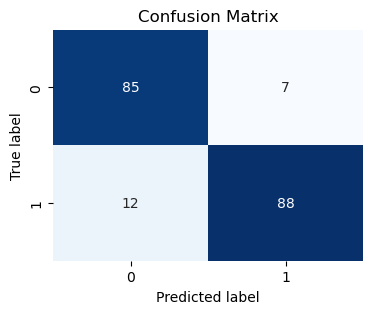

In [69]:
# val = Dataset(docs_val, y_val)
# val_dataloader = torch.utils.data.DataLoader(val, batch_size=16, shuffle=False, worker_init_fn=np.random.seed(0))
# val_acc, val_loss, val_f1, val_report, val_labels, val_preds = evaluate(finetuned_model, val_dataloader)
val_cm = confusion_matrix(val_labels, val_preds)
print("classification report:\n", val_report)
print("confusion matrix:\n", val_cm)
tn, fp, fn, tp = val_cm.ravel().tolist()
print("tn, fp, fn, tp: ", tn, fp, fn, tp)

# Plot confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(val_labels, val_preds)

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=[0, 1], yticklabels=[0, 1])

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.show()

## Try it out on new sentences

In [30]:
def predict_sentiment(text, model, tokenizer, device, max_length=512):
    model.eval()
    encoding = tokenizer(text, return_tensors='pt', max_length=max_length, padding='max_length', truncation=True)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_id=input_ids, mask=attention_mask)
        _, preds = torch.max(outputs, dim=1)
    return "positive" if preds.item() == 1 else "negative"

In [72]:
test_text = "The movie had a great plot twist but the end was too corny. I was expecting the main character to be a bit more developed. Despite that, I'm glad I saw the movie and would recommend it."
sentiment = predict_sentiment(test_text, finetuned_model, tokenizer, device)
print(test_text)
print(f"Predicted sentiment: {sentiment}")

The movie had a great plot twist but the end was too corny. I was expecting the main character to be a bit more developed. Despite that, I'm glad I saw the movie and would recommend it.
Predicted sentiment: negative
